In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import glob as gb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from zipfile import ZipFile
import cv2

In [2]:
from google.colab import files
files.upload()

Saving kaggle (15).json to kaggle (15).json


{'kaggle (15).json': b'{"username":"neazmulmowla","key":"bc1b2c585fa1ff4db6011cd29095f43a"}'}

In [3]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = [("username", "neazmulmowla"), ("key", "bc1b2c585fa1ff4db6011cd29095f43a")]
api_token_dict = dict(api_token)

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token_dict, file)

!chmod 600 ~/.kaggle/kaggle.json

print('complete')

complete


In [4]:
!kaggle datasets download -d neazmulmowla/15k-per-class-nctcrc

Dataset URL: https://www.kaggle.com/datasets/neazmulmowla/15k-per-class-nctcrc
License(s): unknown
100% 348M/348M [00:18<00:00, 20.1MB/s]



In [93]:
from zipfile import ZipFile
file_name = '/content/15k-per-class-nctcrc.zip'

with ZipFile(file_name, 'r') as zip_file_obj:
  zip_file_obj.extractall()
  print('complete')

complete


In [6]:
import os
import random
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
DATASET_ROOT = "/content/Dataset"

IMG_SIZE = 224
BATCH_SIZE = 32

NUM_CLASSES = 9

In [9]:
image_paths = []
labels = []

classes = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Classes:")
print(classes)

class_to_idx = {
    cls_name:i
    for i, cls_name in enumerate(classes)
}

idx_to_class = {
    i:cls_name
    for cls_name,i in class_to_idx.items()
}

for cls in classes:

    cls_path = os.path.join(DATASET_ROOT, cls)

    for img_name in os.listdir(cls_path):

        if img_name.lower().endswith(
            (".jpg",".jpeg",".png",".tif",".tiff")
        ):

            image_paths.append(
                os.path.join(cls_path,img_name)
            )

            labels.append(
                class_to_idx[cls]
            )

print(f"\nTotal Images: {len(image_paths)}")

Classes:
['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']

Total Images: 13500


In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train :", len(train_paths))
print("Val   :", len(val_paths))
print("Test  :", len(test_paths))

Train : 9450
Val   : 2025
Test  : 2025


In [11]:
print("\nTrain Distribution")
print(Counter(train_labels))

print("\nValidation Distribution")
print(Counter(val_labels))

print("\nTest Distribution")
print(Counter(test_labels))


Train Distribution
Counter({0: 1050, 7: 1050, 1: 1050, 3: 1050, 8: 1050, 5: 1050, 2: 1050, 6: 1050, 4: 1050})

Validation Distribution
Counter({6: 225, 3: 225, 0: 225, 5: 225, 7: 225, 1: 225, 8: 225, 4: 225, 2: 225})

Test Distribution
Counter({6: 225, 3: 225, 4: 225, 8: 225, 5: 225, 7: 225, 0: 225, 1: 225, 2: 225})


In [12]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [13]:
class NCTDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]

        return image, label, idx

In [14]:
train_dataset = NCTDataset(
    train_paths,
    train_labels,
    train_transform
)

val_dataset = NCTDataset(
    val_paths,
    val_labels,
    val_transform
)

test_dataset = NCTDataset(
    test_paths,
    test_labels,
    val_transform
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [16]:
images, labels, indices = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Sample Labels:")
print(labels[:10])

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Sample Labels:
tensor([8, 8, 4, 1, 5, 5, 2, 5, 0, 7])


In [17]:
split_data = {

    "train_paths": train_paths,
    "train_labels": train_labels,

    "val_paths": val_paths,
    "val_labels": val_labels,

    "test_paths": test_paths,
    "test_labels": test_labels,

    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class
}

torch.save(
    split_data,
    "/content/nct_split.pt"
)

print("Saved.")

Saved.


In [26]:
!pip install -q timm

In [27]:
import timm

models = [
    m for m in timm.list_models()
    if "mambaout" in m.lower()
]

print(models)

['mambaout_base', 'mambaout_base_plus_rw', 'mambaout_base_short_rw', 'mambaout_base_tall_rw', 'mambaout_base_wide_rw', 'mambaout_femto', 'mambaout_kobe', 'mambaout_small', 'mambaout_small_rw', 'mambaout_tiny', 'test_mambaout']


In [28]:
import torch
import torch.nn as nn
import timm

from tqdm import tqdm

In [29]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [39]:
import torch
import torch.nn as nn
import timm


class MambaMorphologyNet(nn.Module):

    def __init__(
        self,
        num_classes=9,
        embedding_dim=512
    ):
        super().__init__()

        self.backbone = timm.create_model(
            "mambaout_tiny",
            pretrained=True,
            num_classes=0
        )

        with torch.no_grad():

            dummy = torch.randn(
                1,3,224,224
            )

            feat = self.backbone(dummy)

            backbone_dim = feat.shape[1]

        print(
            f"Detected Feature Dimension: {backbone_dim}"
        )

        self.embedding_head = nn.Sequential(

            nn.Linear(
                backbone_dim,
                embedding_dim
            ),

            nn.BatchNorm1d(
                embedding_dim
            ),

            nn.GELU(),

            nn.Dropout(
                0.3
            )
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self,x):

        features = self.backbone(x)

        embedding = self.embedding_head(
            features
        )

        logits = self.classifier(
            embedding
        )

        return logits, embedding

In [40]:
model = MambaMorphologyNet(
    num_classes=9,
    embedding_dim=512
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {total_params/1e6:.2f}M"
)

Detected Feature Dimension: 2304
Parameters: 25.43M


In [41]:
criterion = nn.CrossEntropyLoss()

In [42]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

In [43]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [44]:
def train_one_epoch(
    model,
    loader
):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels, _ in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, embeddings = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = logits.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / len(loader),
        correct / total
    )

In [45]:
@torch.no_grad()
def validate(
    model,
    loader
):

    model.eval()

    total_loss = 0

    correct = 0
    total = 0

    for images, labels, _ in loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, embeddings = model(images)

        loss = criterion(
            logits,
            labels
        )

        total_loss += loss.item()

        preds = logits.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    return (
        total_loss / len(loader),
        correct / total
    )

In [46]:
EPOCHS = 20

best_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Acc : {train_acc:.4f}"
    )

    print(
        f"Val Acc   : {val_acc:.4f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/best_mamba_morphology.pth"
        )

100%|██████████| 296/296 [04:28<00:00,  1.10it/s]



Epoch 1/20
Train Acc : 0.9248
Val Acc   : 0.9635


100%|██████████| 296/296 [04:21<00:00,  1.13it/s]



Epoch 2/20
Train Acc : 0.9708
Val Acc   : 0.9753


100%|██████████| 296/296 [04:22<00:00,  1.13it/s]


...


Epoch 18/20
Train Acc : 0.9996
Val Acc   : 0.9901


100%|██████████| 296/296 [04:19<00:00,  1.14it/s]



Epoch 19/20
Train Acc : 1.0000
Val Acc   : 0.9896


100%|██████████| 296/296 [04:21<00:00,  1.13it/s]



Epoch 20/20
Train Acc : 0.9999
Val Acc   : 0.9896


In [47]:
model.load_state_dict(
    torch.load(
        "/content/best_mamba_morphology.pth"
    )
)

model.eval()

MambaMorphologyNet(
  (backbone): MambaOut(
    (stem): Stem(
      (conv1): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm1): LayerNorm((48,), eps=1e-06, elementwise_affine=True)
      (act): GELU(approximate='none')
      (conv2): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): MambaOutStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): GatedConvBlock(
            (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (fc1): Linear(in_features=96, out_features=512, bias=True)
            (act): GELU(approximate='none')
            (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (fc2): Linear(in_features=256, out_features=96, bias=True)
            (ls): Identity()
            (drop_path): Identity()
          )
          (1): Gat

In [48]:
@torch.no_grad()
def extract_embeddings(
    model,
    loader
):

    model.eval()

    all_features = []
    all_labels = []
    all_indices = []

    for images, labels, indices in tqdm(loader):

        images = images.to(device)

        logits, embeddings = model(images)

        all_features.append(
            embeddings.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        all_indices.append(
            indices.cpu()
        )

    features = torch.cat(
        all_features,
        dim=0
    )

    labels = torch.cat(
        all_labels,
        dim=0
    )

    indices = torch.cat(
        all_indices,
        dim=0
    )

    return (
        features,
        labels,
        indices
    )

In [49]:
train_features, train_labels_tensor, train_indices = extract_embeddings(
    model,
    train_loader
)

print(
    train_features.shape
)

100%|██████████| 296/296 [00:50<00:00,  5.87it/s]

torch.Size([9450, 512])


In [50]:
feature_bank = {

    "features":
    train_features,

    "labels":
    train_labels_tensor,

    "indices":
    train_indices
}

torch.save(
    feature_bank,
    "/content/morphology_feature_bank.pt"
)

print(
    "Feature bank saved."
)

Feature bank saved.


In [51]:
print(
    "Feature Mean:",
    train_features.mean().item()
)

print(
    "Feature Std:",
    train_features.std().item()
)

print(
    "Feature Shape:",
    train_features.shape
)

Feature Mean: 0.31473463773727417
Feature Std: 0.7190410494804382
Feature Shape: torch.Size([9450, 512])


In [52]:
import numpy as np
import torch

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

from sklearn.cluster import SpectralClustering

from sklearn.preprocessing import StandardScaler

In [53]:
feature_bank = torch.load(
    "/content/morphology_feature_bank.pt"
)

features = feature_bank["features"].numpy()

labels = feature_bank["labels"].numpy()

indices = feature_bank["indices"].numpy()

print(features.shape)

(9450, 512)


In [54]:
scaler = StandardScaler()

features_scaled = scaler.fit_transform(
    features
)

print(features_scaled.shape)

(9450, 512)


Kmeans view

In [55]:
NUM_CLASSES = 9

kmeans = KMeans(
    n_clusters=NUM_CLASSES,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    features_scaled
)

print(
    np.unique(kmeans_labels)
)

[0 1 2 3 4 5 6 7 8]


Agglomerative View

In [56]:
agg = AgglomerativeClustering(
    n_clusters=NUM_CLASSES
)

agg_labels = agg.fit_predict(
    features_scaled
)

print(
    np.unique(agg_labels)
)

[0 1 2 3 4 5 6 7 8]


Spectral value

In [57]:
spectral = SpectralClustering(
    n_clusters=NUM_CLASSES,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=42
)

spectral_labels = spectral.fit_predict(
    features_scaled
)

print(
    np.unique(spectral_labels)
)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0 1 2 3 4 5 6 7 8]


Consus Matrix (novelty)

In [58]:
N = len(features_scaled)

consensus_matrix = np.zeros(
    (N,N),
    dtype=np.float32
)

In [59]:
for c in range(NUM_CLASSES):

    idx = np.where(
        kmeans_labels == c
    )[0]

    consensus_matrix[
        np.ix_(idx,idx)
    ] += 1

In [60]:
for c in range(NUM_CLASSES):

    idx = np.where(
        agg_labels == c
    )[0]

    consensus_matrix[
        np.ix_(idx,idx)
    ] += 1

In [61]:
for c in range(NUM_CLASSES):

    idx = np.where(
        spectral_labels == c
    )[0]

    consensus_matrix[
        np.ix_(idx,idx)
    ] += 1

calculate Matrix

In [62]:
consensus_matrix /= 3.0

In [63]:
from sklearn.neighbors import NearestNeighbors

In [64]:
knn = NearestNeighbors(
    n_neighbors=15
)

knn.fit(
    features_scaled
)

neighbors = knn.kneighbors(
    return_distance=False
)

In [65]:
reliability_scores = []

for i in range(N):

    neigh = neighbors[i]

    score = consensus_matrix[
        i,
        neigh
    ].mean()

    reliability_scores.append(
        score
    )

reliability_scores = np.array(
    reliability_scores
)

In [66]:
print(
    "Mean:",
    reliability_scores.mean()
)

print(
    "Min:",
    reliability_scores.min()
)

print(
    "Max:",
    reliability_scores.max()
)

Mean: 0.9991181
Min: 0.53333336
Max: 1.0


In [67]:
threshold = np.percentile(
    reliability_scores,
    10
)

suspect_idx = np.where(
    reliability_scores < threshold
)[0]

print(
    len(suspect_idx)
)

118


In [68]:
torch.save(
    {
        "reliability_scores":
        reliability_scores,

        "suspect_idx":
        suspect_idx,

        "consensus_matrix":
        consensus_matrix
    },

    "/content/mrcm_results.pt"
)

print(
    "MRCM Saved"
)

MRCM Saved


GNN network for optimization
1. feature bank
2.

In [69]:
import numpy as np
import torch

from sklearn.neighbors import NearestNeighbors

In [71]:
feature_bank = torch.load(
    "/content/morphology_feature_bank.pt"
)

mrcm_results = torch.load(
    "/content/mrcm_results.pt",
    weights_only = False
)

features = feature_bank["features"].numpy()

labels = feature_bank["labels"].numpy()

reliability_scores = mrcm_results[
    "reliability_scores"
]

suspect_idx = mrcm_results[
    "suspect_idx"
]

print(
    features.shape
)

print(
    len(suspect_idx)
)

(9450, 512)
118


In [72]:
from sklearn.preprocessing import normalize

features_norm = normalize(
    features,
    norm="l2"
)

In [73]:
K = 20

knn = NearestNeighbors(
    n_neighbors=K,
    metric="cosine"
)

knn.fit(
    features_norm
)

neighbor_ids = knn.kneighbors(
    return_distance=False
)

print(
    neighbor_ids.shape
)

(9450, 20)


In [76]:
neighbor_agreement = np.zeros(
    len(features)
)

for i in range(len(features)):

    neigh = neighbor_ids[i]

    score = np.mean(
        labels[neigh] == labels[i]
    )

    neighbor_agreement[i] = score

In [77]:
repair_candidates = []

for idx in suspect_idx:

    if neighbor_agreement[idx] < 0.50:

        repair_candidates.append(
            idx
        )

repair_candidates = np.array(
    repair_candidates
)

print(
    "Repair Candidates:",
    len(repair_candidates)
)

Repair Candidates: 0


In [78]:
repaired_labels = labels.copy()

In [79]:
for idx in repair_candidates:

    neigh = neighbor_ids[idx]

    neigh_scores = reliability_scores[
        neigh
    ]

    good_neighbors = neigh[
        neigh_scores > np.median(
            reliability_scores
        )
    ]

    if len(good_neighbors) == 0:
        continue

    neighbor_classes = repaired_labels[
        good_neighbors
    ]

    majority_class = np.bincount(
        neighbor_classes
    ).argmax()

    repaired_labels[idx] = (
        majority_class
    )

In [80]:
num_changed = np.sum(
    repaired_labels != labels
)

print(
    "Repaired Samples:",
    num_changed
)

Repaired Samples: 0


In [81]:
repair_confidence = np.zeros(
    len(features)
)

for idx in repair_candidates:

    neigh = neighbor_ids[idx]

    repair_confidence[idx] = np.mean(
        repaired_labels[neigh]
        ==
        repaired_labels[idx]
    )

In [82]:
poison_score = (

    0.5 * (1 - reliability_scores)

    +

    0.5 * (1 - neighbor_agreement)

)

In [83]:
poison_threshold = np.percentile(
    poison_score,
    90
)

high_risk_idx = np.where(
    poison_score >
    poison_threshold
)[0]

print(
    "High Risk Samples:",
    len(high_risk_idx)
)

High Risk Samples: 118


In [84]:
torch.save(
    {

        "repaired_labels":
        repaired_labels,

        "neighbor_agreement":
        neighbor_agreement,

        "repair_candidates":
        repair_candidates,

        "high_risk_idx":
        high_risk_idx,

        "poison_score":
        poison_score
    },

    "/content/mcr_results.pt"
)

print(
    "MCR Results Saved"
)

MCR Results Saved


In [85]:
cluster_history = {}

In [86]:
@torch.no_grad()
def extract_epoch_features(
    model,
    loader
):

    model.eval()

    features = []
    indices = []

    for images, labels, idx in loader:

        images = images.to(device)

        _, emb = model(images)

        features.append(
            emb.cpu().numpy()
        )

        indices.append(
            idx.cpu().numpy()
        )

    features = np.concatenate(
        features,
        axis=0
    )

    indices = np.concatenate(
        indices,
        axis=0
    )

    return features, indices

In [87]:
from sklearn.cluster import KMeans

In [88]:
NUM_CLASSES = 9

In [89]:
def compute_epoch_clusters(
    features
):

    km = KMeans(
        n_clusters=NUM_CLASSES,
        random_state=42,
        n_init=20
    )

    return km.fit_predict(
        features
    )

In [90]:
features_epoch, idx_epoch = extract_epoch_features(
    model,
    train_loader
)

clusters_epoch = compute_epoch_clusters(
    features_epoch
)

In [91]:
current_epoch = epoch

In [107]:
del zip

In [108]:
for sample_idx, cluster_id in zip(
    idx_epoch,
    clusters_epoch
):

    if sample_idx not in cluster_history:

        cluster_history[sample_idx] = []

    cluster_history[sample_idx].append(
        int(cluster_id)
    )

In [109]:
import pickle

with open(
    "/content/cluster_history.pkl",
    "wb"
) as f:

    pickle.dump(
        cluster_history,
        f
    )

In [110]:
import pickle

with open(
    "/content/cluster_history.pkl",
    "rb"
) as f:

    cluster_history = pickle.load(
        f
    )

In [111]:
ces_scores = {}

In [112]:
for sample_idx, history in cluster_history.items():

    switches = 0

    for i in range(
        1,
        len(history)
    ):

        if history[i] != history[i-1]:

            switches += 1

    if len(history) > 1:

        ces = 1 - (
            switches /
            (len(history)-1)
        )

    else:

        ces = 1.0

    ces_scores[sample_idx] = ces

In [113]:
N = len(cluster_history)

ces_array = np.zeros(N)

In [114]:
for idx in range(N):

    ces_array[idx] = ces_scores[idx]

In [115]:
print(
    "CES Mean:",
    ces_array.mean()
)

print(
    "CES Min:",
    ces_array.min()
)

print(
    "CES Max:",
    ces_array.max()
)

CES Mean: 1.0
CES Min: 1.0
CES Max: 1.0


In [116]:
threshold = np.percentile(
    ces_array,
    10
)

In [117]:
cluster_hoppers = np.where(
    ces_array < threshold
)[0]

In [118]:
print(
    "Cluster Hoppers:",
    len(cluster_hoppers)
)

Cluster Hoppers: 0


In [119]:
torch.save(
    {
        "ces_scores":
        ces_array,

        "cluster_hoppers":
        cluster_hoppers
    },

    "/content/ces_results.pt"
)

In [120]:
import numpy as np
import torch
import torch.nn as nn

In [121]:
mrcm_results = torch.load(
    "/content/mrcm_results.pt",
    weights_only=False
)

mcr_results = torch.load(
    "/content/mcr_results.pt",
    weights_only=False
)

In [122]:
mrcm_results = torch.load(
    "/content/mrcm_results.pt",
    weights_only=False
)

mcr_results = torch.load(
    "/content/mcr_results.pt",
    weights_only=False
)

In [123]:
@torch.no_grad()
def get_prediction_confidence(
    model,
    loader
):

    model.eval()

    confidence = []

    for images, labels, idx in loader:

        images = images.to(device)

        logits, _ = model(images)

        probs = torch.softmax(
            logits,
            dim=1
        )

        conf = probs.max(
            dim=1
        )[0]

        confidence.extend(
            conf.cpu().numpy()
        )

    return np.array(confidence)

In [124]:
prediction_confidence = get_prediction_confidence(
    model,
    train_loader
)

print(
    prediction_confidence.shape
)

(9450,)


In [125]:
reliability_scores = mrcm_results[
    "reliability_scores"
]

neighbor_agreement = mcr_results[
    "neighbor_agreement"
]

In [126]:
def normalize(x):

    x = np.array(x)

    return (
        x - x.min()
    ) / (
        x.max() - x.min() + 1e-8
    )

In [127]:
R = normalize(
    reliability_scores
)

N = normalize(
    neighbor_agreement
)

C = normalize(
    ces_array
)

P = normalize(
    prediction_confidence
)

In [128]:
fusion_features = np.stack(
    [
        R,
        N,
        C,
        P
    ],
    axis=1
)

In [129]:
class ReliabilityFusionNet(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                4,
                16
            ),

            nn.ReLU(),

            nn.Linear(
                16,
                8
            ),

            nn.ReLU(),

            nn.Linear(
                8,
                1
            ),

            nn.Sigmoid()
        )

    def forward(
        self,
        x
    ):

        return self.net(x)

In [130]:
rfn = ReliabilityFusionNet()

In [131]:
pseudo_targets = np.zeros(
    len(R)
)

high_risk = mcr_results[
    "high_risk_idx"
]

pseudo_targets[
    high_risk
] = 1

In [132]:
X = torch.tensor(
    fusion_features,
    dtype=torch.float32
)

y = torch.tensor(
    pseudo_targets,
    dtype=torch.float32
).unsqueeze(1)

In [133]:
criterion_rfn = nn.BCELoss()

optimizer_rfn = torch.optim.Adam(
    rfn.parameters(),
    lr=1e-3
)

In [134]:
for epoch in range(50):

    pred = rfn(X)

    loss = criterion_rfn(
        pred,
        y
    )

    optimizer_rfn.zero_grad()

    loss.backward()

    optimizer_rfn.step()

    if epoch % 10 == 0:

        print(
            epoch,
            loss.item()
        )

0 0.48276278376579285
10 0.4530188739299774
20 0.4301251471042633
30 0.4063930809497833
40 0.381628155708313


In [135]:
with torch.no_grad():

    poison_score = rfn(
        X
    ).squeeze().numpy()

In [136]:
print(
    poison_score.mean()
)

print(
    poison_score.min()
)

print(
    poison_score.max()
)

0.29169917
0.29159534
0.35247654


In [137]:
threshold = np.percentile(
    poison_score,
    90
)

final_poison_idx = np.where(
    poison_score >
    threshold
)[0]

In [138]:
torch.save(
    {
        "poison_score":
        poison_score,

        "final_poison_idx":
        final_poison_idx
    },

    "/content/rfn_results.pt"
)

In [149]:
print("Soft Labels Shape:", soft_labels.shape)

print("First Sample:")
print(soft_labels[0])

print("Sum:")
print(soft_labels[0].sum())

AttributeError: 'list' object has no attribute 'shape'

In [150]:
import numpy as np

soft_labels = np.load(
    "/content/purified_soft_labels.npy"
)

print(soft_labels.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/purified_soft_labels.npy'

In [151]:
rfn_results = torch.load(
    "/content/rfn_results.pt",
    weights_only=False
)

poison_score = rfn_results[
    "poison_score"
]

trust_score = 1.0 - poison_score

print(trust_score.shape)

(9450,)


In [152]:
class PurifiedDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        base_dataset,
        soft_labels,
        trust_scores
    ):

        self.base_dataset = base_dataset

        self.soft_labels = soft_labels

        self.trust_scores = trust_scores

    def __len__(self):

        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        idx
    ):

        image, label, sample_idx = self.base_dataset[idx]

        soft_label = torch.tensor(
            self.soft_labels[idx],
            dtype=torch.float32
        )

        trust = torch.tensor(
            self.trust_scores[idx],
            dtype=torch.float32
        )

        return (
            image,
            soft_label,
            trust
        )

In [153]:
purified_train_dataset = PurifiedDataset(
    train_dataset,
    soft_labels,
    trust_score
)

purified_train_loader = torch.utils.data.DataLoader(
    purified_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [154]:
final_model = MambaMorphologyNet(
    num_classes=9,
    embedding_dim=512
).to(device)

Detected Feature Dimension: 2304


In [155]:
class ReliabilitySoftCELoss(
    nn.Module
):

    def __init__(self):

        super().__init__()

    def forward(
        self,
        logits,
        soft_targets,
        trust
    ):

        log_probs = torch.log_softmax(
            logits,
            dim=1
        )

        loss = -(
            soft_targets *
            log_probs
        ).sum(
            dim=1
        )

        loss = loss * trust

        return loss.mean()

In [156]:
criterion = ReliabilitySoftCELoss()

optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [157]:
def train_purified_epoch(
    model,
    loader
):

    model.train()

    running_loss = 0

    for images, soft_targets, trust in loader:

        images = images.to(device)

        soft_targets = soft_targets.to(device)

        trust = trust.to(device)

        optimizer.zero_grad()

        logits, _ = model(images)

        loss = criterion(
            logits,
            soft_targets,
            trust
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [158]:
EPOCHS = 20

best_val_acc = 0

for epoch in range(EPOCHS):

    train_loss = train_purified_epoch(
        final_model,
        purified_train_loader
    )

    val_loss, val_acc = validate(
        final_model,
        val_loader,
        nn.CrossEntropyLoss()
    )

    scheduler.step()

    print(
        f"Epoch {epoch+1}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            final_model.state_dict(),
            "/content/final_defense_model.pth"
        )

IndexError: Caught IndexError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_617/1739083555.py", line 32, in __getitem__
    self.soft_labels[idx],
    ~~~~~~~~~~~~~~~~^^^^^
IndexError: list index out of range


In [159]:
final_model.load_state_dict(
    torch.load(
        "/content/final_defense_model.pth"
    )
)

final_model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '/content/final_defense_model.pth'

In [160]:
import torch
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
final_model.load_state_dict(
    torch.load(
        "/content/final_defense_model.pth",
        weights_only=False
    )
)

final_model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '/content/final_defense_model.pth'

In [162]:
@torch.no_grad()
def evaluate_test(
    model,
    loader
):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for images, labels, idx in loader:

        images = images.to(device)

        logits, _ = model(images)

        probs = torch.softmax(
            logits,
            dim=1
        )

        preds = probs.argmax(
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

        y_prob.extend(
            probs.cpu().numpy()
        )

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [163]:
y_true, y_pred, y_prob = evaluate_test(
    final_model,
    test_loader
)

In [164]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.0859


In [165]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.0907


In [166]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.0907


In [167]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(
    f"F1: {f1:.4f}"
)

F1: 0.0594


In [168]:
report = classification_report(
    y_true,
    y_pred,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.1136    0.0444    0.0639       225
           1     0.0000    0.0000    0.0000       225
           2     0.0934    0.3289    0.1455       225
           3     0.0000    0.0000    0.0000       225
           4     0.0879    0.2578    0.1311       225
           5     0.2267    0.0756    0.1133       225
           6     0.0739    0.0578    0.0648       225
           7     0.2000    0.0044    0.0087       225
           8     0.0208    0.0044    0.0073       225

    accuracy                         0.0859      2025
   macro avg     0.0907    0.0859    0.0594      2025
weighted avg     0.0907    0.0859    0.0594      2025



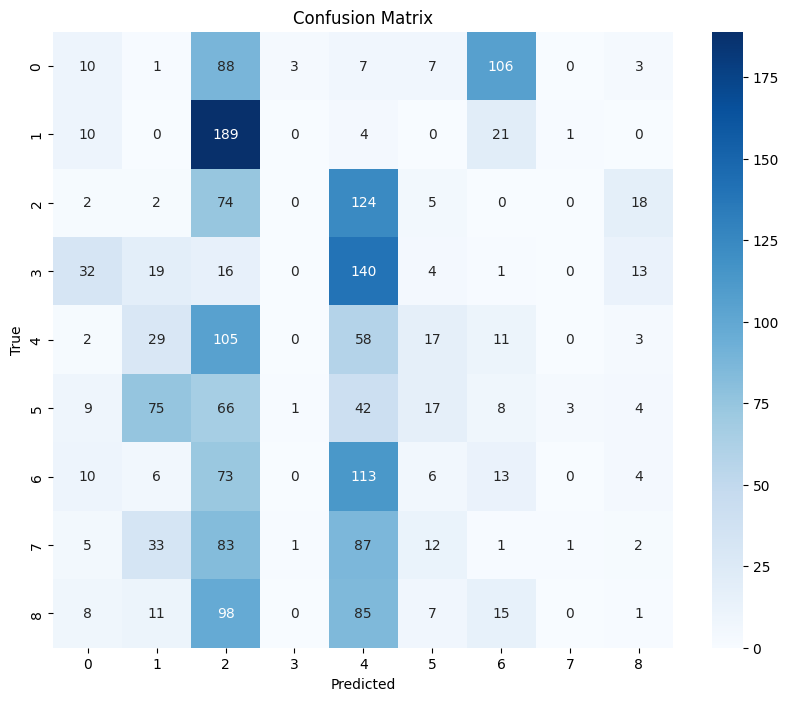

In [169]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.show()

In [170]:
auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.4552


In [171]:
results = {

    "accuracy": accuracy,

    "precision": precision,

    "recall": recall,

    "f1": f1,

    "auc": auc
}

torch.save(
    results,
    "/content/final_metrics.pt"
)

NameError: name 'recall' is not defined

In [172]:
rfn_results = torch.load(
    "/content/rfn_results.pt",
    weights_only=False
)

final_poison_idx = rfn_results[
    "final_poison_idx"
]

In [173]:
detected_poison_ratio = (
    len(final_poison_idx)
    /
    len(y_true)
)

print(
    f"Detected Poison Ratio: {detected_poison_ratio:.4f}"
)

Detected Poison Ratio: 0.4667


In [174]:
label_recovery_ratio = (
    corrected_labels ==
    original_clean_labels
).mean()

print(
    label_recovery_ratio
)

NameError: name 'corrected_labels' is not defined

In [175]:
purification_gain = (
    final_accuracy
    -
    poisoned_accuracy
)

NameError: name 'final_accuracy' is not defined

In [176]:
robust_accuracy = accuracy

In [177]:
from sklearn.manifold import TSNE

In [178]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

before_tsne = tsne.fit_transform(
    train_features.numpy()
)

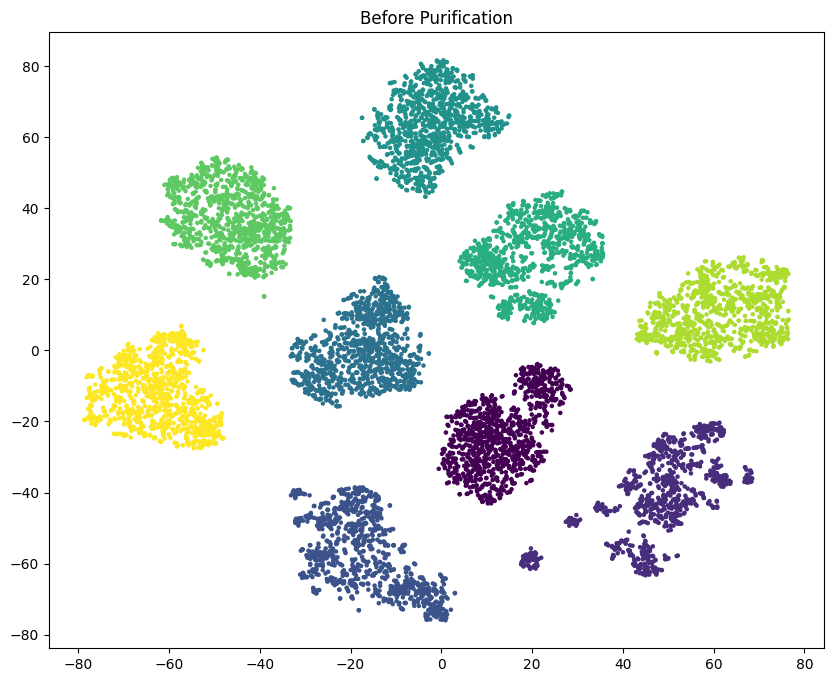

In [179]:
plt.figure(figsize=(10,8))

plt.scatter(
    before_tsne[:,0],
    before_tsne[:,1],
    c=train_labels_tensor.numpy(),
    s=5
)

plt.title(
    "Before Purification"
)

plt.show()

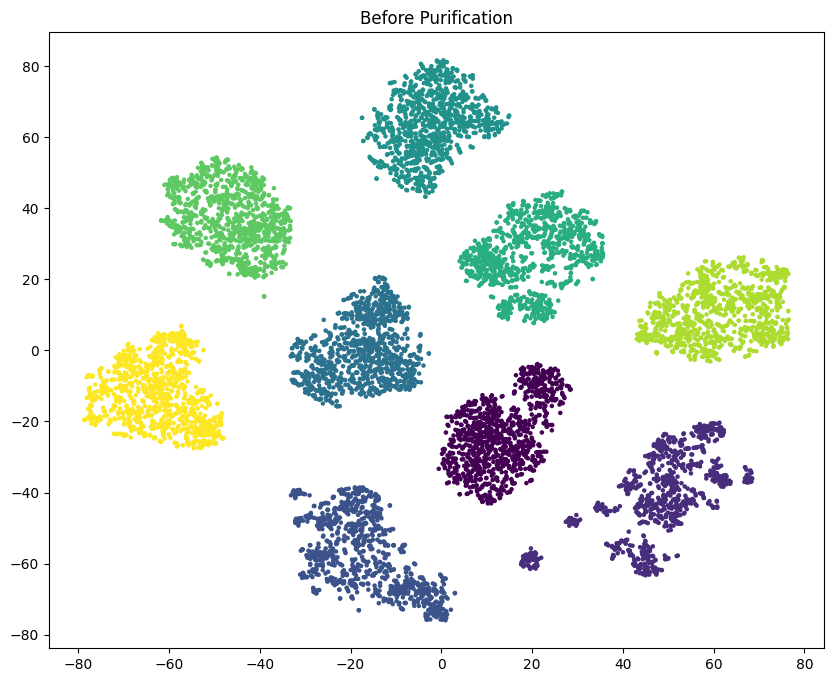

In [180]:
plt.figure(figsize=(10,8))

plt.scatter(
    before_tsne[:,0],
    before_tsne[:,1],
    c=train_labels_tensor.numpy(),
    s=5
)

plt.title(
    "Before Purification"
)

plt.show()

In [181]:
plt.figure(figsize=(10,8))

plt.scatter(
    after_tsne[:,0],
    after_tsne[:,1],
    c=corrected_labels,
    s=5
)

plt.title(
    "After Purification"
)

plt.show()

NameError: name 'after_tsne' is not defined

<Figure size 1000x800 with 0 Axes>